<div align="center">

# Universidad Nacional Autónoma de México

## Facultad de Ingeniería

<br>

# Proyecto final

## Modelo dinámico de un robot manipulador 3R

<br>

**Asignatura:** Robótica
**Profesor:** M.I. Erik Peña Medina
**Semestre:** 2026-2

<br>

**Integrantes:**
Baruch Villarreal Hinojosa
Luis Ángel Pérez Castro

<br>

**Fecha de entrega:** 10jun2026

</div>

---



---

## Descripción general del proyecto

En este proyecto se realiza la obtención de parámetros físicos de un robot manipulador 3R a partir de su modelo CAD. Se identifican las principales dimensiones geométricas, masas, centros de masa y momentos de inercia de los eslabones. Posteriormente, estos datos se convierten al Sistema Internacional y se utilizan para generar el modelo dinámico del robot mediante una formulación basada en energía.

El modelo dinámico se expresa de forma general como:
$$
\tau = M(q)\ddot{q} + C(q,\dot{q})\dot{q} + G(q)
$$

donde:

$M(q)$ representa la matriz de inercia del robot.
$C(q,\dot{q})$ contiene los términos centrífugos y de Coriolis.
$G(q)$ representa el vector de efectos gravitacionales.
$\tau$ corresponde al vector de torques articulares.
$q$, $\dot{q}$ y $\ddot{q}$ representan la posición, velocidad y aceleración articular, respectivamente.


# Índice

1. Hipótesis
2. Objetivo
3. Introducción
4. Descripción del robot 3R
5. Obtención de datos desde CAD
6. Conversión de unidades
7. Parámetros físicos del robot
8. Modelo cinemático
9. Modelo dinámico
10. Sustitución de parámetros
11. Resultados y pruebas del modelo
12. Discusión de resultados
13. Conclusiones
14. Referencias

---

# 1. Hipótesis

Es posible obtener los parámetros físicos principales de un robot manipulador 3R a partir de un modelo CAD y utilizarlos para generar un modelo dinámico que describa la relación entre el movimiento articular y los torques requeridos en cada articulación.

A partir de las masas, centros de masa, momentos de inercia y dimensiones geométricas del robot, se puede formular un modelo dinámico mediante el método de Euler-Lagrange. Dicho modelo permite representar el comportamiento del robot en función de sus posiciones, velocidades y aceleraciones articulares.

---

# 2. Objetivo

Obtener los datos geométricos, másicos e inerciales de un robot manipulador 3R a partir de su modelo CAD y generar su modelo dinámico mediante una formulación basada en energía.

El modelo dinámico obtenido tendrá como finalidad estimar los torques requeridos por las articulaciones del robot durante una trayectoria de prueba, expresando el sistema en la forma general:

$$
\tau = M(q)\ddot{q} + C(q,\dot{q})\dot{q} + G(q)
$$

donde:

* $M(q)$ representa la matriz de inercia.
* $C(q,\dot{q})$ contiene los términos centrífugos y de Coriolis.
* $G(q)$ representa los efectos gravitacionales.
* $\tau$ representa el vector de torques articulares.
* $q$, $\dot{q}$ y $\ddot{q}$ representan posición, velocidad y aceleración articular.


# 3. Introducción

El modelado dinámico de robots manipuladores es una herramienta fundamental para analizar el comportamiento mecánico de un sistema robótico durante su movimiento. A diferencia del modelo cinemático, que únicamente describe la relación entre las variables articulares y la posición del efector final, el modelo dinámico permite estudiar la relación entre el movimiento, las masas, las inercias y los torques requeridos por los actuadores.

En un robot manipulador de tres grados de libertad rotacionales, conocido como robot 3R, cada articulación genera un movimiento angular que modifica la configuración completa del mecanismo. Por esta razón, el torque necesario en cada motor no depende únicamente de su propia articulación, sino también de la posición, velocidad y aceleración de las demás articulaciones. Además, influyen directamente las propiedades físicas de cada eslabón, como su masa, centro de masa y momento de inercia.

Para generar un modelo dinámico representativo, es necesario obtener previamente los parámetros físicos del robot. En este proyecto dichos parámetros se obtienen a partir de un modelo CAD del manipulador. El modelo CAD permite identificar las dimensiones principales del robot, así como extraer datos de masa, centro de masa y momentos de inercia de los eslabones que conforman el mecanismo.

Posteriormente, los datos obtenidos se convierten al Sistema Internacional de unidades y se utilizan para formular el modelo dinámico mediante el método de Euler-Lagrange. Este método parte de la energía cinética y potencial del sistema para obtener las ecuaciones de movimiento del robot. De esta manera, el modelo resultante puede expresarse en forma matricial como:

$$
\tau = M(q)\ddot{q} + C(q,\dot{q})\dot{q} + G(q)
$$

donde $M(q)$ corresponde a la matriz de inercia, $C(q,\dot{q})$ agrupa los términos centrífugos y de Coriolis, $G(q)$ representa los efectos gravitacionales y $\tau$ es el vector de torques articulares.

El desarrollo de este proyecto permite integrar el análisis geométrico, la obtención de parámetros físicos desde CAD y la formulación dinámica de un robot manipulador 3R. Con ello se busca obtener un modelo que permita estimar el comportamiento dinámico del robot y servir como base para análisis posteriores de simulación, control o selección de actuadores.


# 4. Descripción del robot 3R

El sistema analizado corresponde a un robot manipulador serial de tres grados de libertad rotacionales, por lo que se considera un robot de tipo 3R. Este tipo de robot está formado por una cadena cinemática abierta, en la cual cada articulación permite un movimiento angular relativo entre dos eslabones consecutivos.

El robot utilizado en este proyecto fue obtenido a partir de un modelo CAD. En el ensamble se identificaron una base fija y tres eslabones principales asociados al movimiento del manipulador. Para efectos del modelo dinámico, la base se considera como un elemento fijo de soporte, mientras que los eslabones móviles corresponden a `link_1`, `link_2` y `link_3`.

<div align="center">

![Modelo CAD del robot 3R](imagenes/robot_completo.jpeg)

*Figura 1. Modelo CAD del robot manipulador 3R.*

</div>

La estructura general del robot se interpreta de la siguiente manera:

* `base_baselink`: elemento fijo del robot. Sirve como soporte estructural y punto de referencia para el sistema.
* `link_1`: primer eslabón móvil asociado al giro de la base o primera articulación.
* `link_2`: segundo eslabón móvil, correspondiente al brazo principal del manipulador.
* `link_3`: tercer eslabón móvil, correspondiente al antebrazo o sección final del robot.
* Efector final: extensión final del mecanismo, utilizada como referencia para la posición de salida del robot.

Para el desarrollo del modelo se definen tres coordenadas articulares:

$$
q =
\begin{bmatrix}
q_1 \
q_2 \
q_3
\end{bmatrix}
$$

donde:

* $q_1$ representa la rotación de la base.
* $q_2$ representa la rotación del brazo principal.
* $q_3$ representa la rotación del antebrazo.

El modelo dinámico se obtiene considerando los tres eslabones móviles del robot. Cada eslabón posee una masa, un centro de masa y una matriz de inercia, datos que fueron extraídos del modelo CAD. Estos parámetros permiten representar de forma más realista la distribución de masa del sistema y son necesarios para calcular la energía cinética, la energía potencial y los torques articulares.

La geometría principal del robot fue obtenida mediante mediciones entre ejes de articulación. Las distancias utilizadas en el modelo son:

| Parámetro | Valor CAD | Valor en SI | Descripción                                                            |
| --------- | --------: | ----------: | ---------------------------------------------------------------------- |
| $d_1$     |  45.52 mm |   0.04552 m | Offset vertical desde la base fija hasta la primera articulación móvil |
| $L_2$     | 237.93 mm |   0.23793 m | Longitud del brazo principal, de hombro a codo                         |
| $L_3$     | 215.99 mm |   0.21599 m | Longitud del antebrazo, de codo a articulación final                   |
| $L_e$     |  69.96 mm |   0.06996 m | Longitud aproximada del efector final                                  |

Estas dimensiones se utilizarán posteriormente para formular el modelo cinemático del robot y para definir la posición de los centros de masa de cada eslabón dentro del modelo dinámico.


## 4.1 Identificación de los eslabones del robot

A partir del ensamble CAD se identificaron los principales componentes del robot. La base se considera fija, mientras que los tres eslabones móviles se utilizan para formular el modelo dinámico del manipulador 3R.

<div align="center">

![Base del robot](imagenes/base.png)

*Figura 2. Base fija del robot.*

</div>

<div align="center">

![Primer eslabón](imagenes/link1.jpeg)

*Figura 3. Primer eslabón móvil del robot.*

</div>

<div align="center">

![Segundo eslabón](imagenes/link2.jpeg)

*Figura 4. Segundo eslabón móvil o brazo principal.*

</div>

<div align="center">

![Tercer eslabón](imagenes/link3.jpeg)

*Figura 5. Tercer eslabón móvil o antebrazo.*

</div>

<div align="center">

![Efector final](imagenes/link4.jpeg)

*Figura 6. Efector final o extensión del robot.*

</div>

La identificación de estos elementos permite asociar cada cuerpo del modelo CAD con las variables dinámicas del robot. En particular, los eslabones `link_1`, `link_2` y `link_3` serán utilizados para obtener las expresiones de energía cinética y energía potencial del sistema.


# 5. Obtención de datos desde CAD

Los parámetros físicos del robot se obtuvieron a partir del modelo CAD del manipulador. Para cada componente principal se consultaron sus propiedades físicas, incluyendo masa, volumen, centro de masa y matriz de inercia respecto al centro de masa.

El modelo CAD proporciona los datos en las siguientes unidades:

* Masa en gramos ([g]).
* Longitudes y centros de masa en milímetros ([mm]).
* Momentos de inercia en gramos por milímetro cuadrado ([g \cdot mm^2]).

Para poder utilizar estos valores en el modelo dinámico, todos los parámetros deben convertirse al Sistema Internacional de unidades:

$$
1 \ g = 10^{-3} \ kg
$$

$$
1 \ mm = 10^{-3} \ m
$$

$$
1 \ g \cdot mm^2 = 10^{-9} \ kg \cdot m^2
$$

La base del robot se considera como un elemento fijo de soporte. Sin embargo, sus propiedades físicas también se documentan como referencia del ensamble completo. Para el modelo dinámico del robot 3R se utilizan principalmente los eslabones móviles `link_1`, `link_2` y `link_3`.

## 5.1 Datos físicos obtenidos del CAD

| Componente      | Masa [g] | Centro de masa [mm]           |
| --------------- | -------: | ----------------------------- |
| `base_baselink` |   414.47 | $(9.975,\ -0.782,\ 33.589)$   |
| `link_1`        |   206.09 | $(9.849,\ -0.491,\ 102.507)$  |
| `link_2`        |  449.871 | $(37.603,\ 0.518,\ 238.403)$  |
| `link_3`        |  275.269 | $(203.175,\ 5.870,\ 339.113)$ |

## 5.2 Momentos de inercia respecto al centro de masa

Los momentos de inercia fueron extraídos directamente del software CAD respecto al centro de masa de cada componente. Estos valores son necesarios para calcular la energía cinética rotacional de cada eslabón.

### Base fija

$$
I_{base} =
\begin{bmatrix}
4.826\times10^5 & 957.324 & -50985.738 \
957.324 & 5.322\times10^5 & -2510.008 \
-50985.738 & -2510.008 & 2.954\times10^5
\end{bmatrix}
\ g\cdot mm^2
$$

### Link 1

$$
I_1 =
\begin{bmatrix}
1.632\times10^5 & 3777.20 & 0 \
3777.20 & 65318.055 & -6.818\times10^{-7} \
0 & -6.818\times10^{-7} & 1.370\times10^5
\end{bmatrix}
\ g\cdot mm^2
$$

### Link 2

$$
I_2 =
\begin{bmatrix}
2.108\times10^6 & -1411.922 & -5.025\times10^5 \
-1411.922 & 2.146\times10^6 & -14655.292 \
-5.025\times10^5 & -14655.292 & 2.741\times10^5
\end{bmatrix}
\ g\cdot mm^2
$$

### Link 3

$$
I_3 =
\begin{bmatrix}
55995.297 & -60678.178 & 1.428\times10^5 \
-60678.178 & 1.945\times10^6 & 5245.24 \
1.428\times10^5 & 5245.24 & 1.947\times10^6
\end{bmatrix}
\ g\cdot mm^2
$$

Estos parámetros constituyen la base física del modelo dinámico. En la siguiente sección se realiza la conversión de unidades para poder emplearlos en las ecuaciones de movimiento del robot.


import numpy as np
import pandas as pd

# ---------------------------------------------------------
# Conversión de unidades
# ---------------------------------------------------------
g_to_kg = 1e-3
mm_to_m = 1e-3
gmm2_to_kgm2 = 1e-9

# ---------------------------------------------------------
# Parámetros geométricos medidos en CAD
# ---------------------------------------------------------
d1_mm = 45.52
L2_mm = 237.93
L3_mm = 215.99
Le_mm = 69.96

d1 = d1_mm * mm_to_m
L2 = L2_mm * mm_to_m
L3 = L3_mm * mm_to_m
Le = Le_mm * mm_to_m

geometria = pd.DataFrame({
    "Parámetro": ["d1", "L2", "L3", "Le"],
    "Valor CAD [mm]": [d1_mm, L2_mm, L3_mm, Le_mm],
    "Valor SI [m]": [d1, L2, L3, Le],
    "Descripción": [
        "Offset vertical de la base a la primera articulación móvil",
        "Longitud del brazo principal",
        "Longitud del antebrazo",
        "Longitud aproximada del efector final"
    ]
})

geometria

import numpy as np
import pandas as pd

# ---------------------------------------------------------
# Conversión de unidades
# ---------------------------------------------------------
g_to_kg = 1e-3
mm_to_m = 1e-3
gmm2_to_kgm2 = 1e-9

# ---------------------------------------------------------
# Parámetros geométricos medidos en CAD
# ---------------------------------------------------------
d1_mm = 45.52
L2_mm = 237.93
L3_mm = 215.99
Le_mm = 69.96

d1 = d1_mm * mm_to_m
L2 = L2_mm * mm_to_m
L3 = L3_mm * mm_to_m
Le = Le_mm * mm_to_m

geometria = pd.DataFrame({
    "Parámetro": ["d1", "L2", "L3", "Le"],
    "Valor CAD [mm]": [d1_mm, L2_mm, L3_mm, Le_mm],
    "Valor SI [m]": [d1, L2, L3, Le],
    "Descripción": [
        "Offset vertical de la base a la primera articulación móvil",
        "Longitud del brazo principal",
        "Longitud del antebrazo",
        "Longitud aproximada del efector final"
    ]
})

geometria

In [1]:
import numpy as np
import pandas as pd

# Conversión de unidades
g_to_kg = 1e-3
mm_to_m = 1e-3
gmm2_to_kgm2 = 1e-9

# Parámetros geométricos medidos en CAD
d1_mm = 45.52
L2_mm = 237.93
L3_mm = 215.99
Le_mm = 69.96

d1 = d1_mm * mm_to_m
L2 = L2_mm * mm_to_m
L3 = L3_mm * mm_to_m
Le = Le_mm * mm_to_m

geometria = pd.DataFrame({
    "Parámetro": ["d1", "L2", "L3", "Le"],
    "Valor CAD [mm]": [d1_mm, L2_mm, L3_mm, Le_mm],
    "Valor SI [m]": [d1, L2, L3, Le],
    "Descripción": [
        "Offset vertical de la base a la primera articulación móvil",
        "Longitud del brazo principal",
        "Longitud del antebrazo",
        "Longitud aproximada del efector final"
    ]
})

geometria

,Parámetro,Valor CAD [mm],Valor SI [m],Descripción
0,d1,45.52,0.04552,Offset vertical de la base a la primera articu...
1,L2,237.93,0.23793,Longitud del brazo principal
2,L3,215.99,0.21599,Longitud del antebrazo
3,Le,69.96,0.06996,Longitud aproximada del efector final


In [2]:
# ---------------------------------------------------------
# Datos físicos obtenidos del CAD
# ---------------------------------------------------------

datos_cad = {
    "base_baselink": {
        "masa_g": 414.47,
        "com_mm": np.array([9.975, -0.782, 33.589]),
        "I_gmm2": np.array([
            [4.826e5, 957.324, -50985.738],
            [957.324, 5.322e5, -2510.008],
            [-50985.738, -2510.008, 2.954e5]
        ])
    },
    "link_1": {
        "masa_g": 206.09,
        "com_mm": np.array([9.849, -0.491, 102.507]),
        "I_gmm2": np.array([
            [1.632e5, 3777.20, 0.0],
            [3777.20, 65318.055, -6.818e-7],
            [0.0, -6.818e-7, 1.370e5]
        ])
    },
    "link_2": {
        "masa_g": 449.871,
        "com_mm": np.array([37.603, 0.518, 238.403]),
        "I_gmm2": np.array([
            [2.108e6, -1411.922, -5.025e5],
            [-1411.922, 2.146e6, -14655.292],
            [-5.025e5, -14655.292, 2.741e5]
        ])
    },
    "link_3": {
        "masa_g": 275.269,
        "com_mm": np.array([203.175, 5.870, 339.113]),
        "I_gmm2": np.array([
            [55995.297, -60678.178, 1.428e5],
            [-60678.178, 1.945e6, 5245.24],
            [1.428e5, 5245.24, 1.947e6]
        ])
    }
}

# ---------------------------------------------------------
# Conversión a Sistema Internacional
# ---------------------------------------------------------

datos_si = {}

for nombre, datos in datos_cad.items():
    datos_si[nombre] = {
        "masa_kg": datos["masa_g"] * g_to_kg,
        "com_m": datos["com_mm"] * mm_to_m,
        "I_kgm2": datos["I_gmm2"] * gmm2_to_kgm2
    }

# ---------------------------------------------------------
# Tabla resumen de masas y centros de masa
# ---------------------------------------------------------

tabla_parametros = []

for nombre, datos in datos_si.items():
    tabla_parametros.append({
        "Componente": nombre,
        "Masa [kg]": datos["masa_kg"],
        "COM x [m]": datos["com_m"][0],
        "COM y [m]": datos["com_m"][1],
        "COM z [m]": datos["com_m"][2]
    })

tabla_parametros = pd.DataFrame(tabla_parametros)
tabla_parametros

,Componente,Masa [kg],COM x [m],COM y [m],COM z [m]
0,base_baselink,0.414470,0.009975,-0.000782,0.033589
1,link_1,0.206090,0.009849,-0.000491,0.102507
2,link_2,0.449871,0.037603,0.000518,0.238403
3,link_3,0.275269,0.203175,0.005870,0.339113


In [3]:
# ---------------------------------------------------------
# Matrices de inercia convertidas a kg·m²
# ---------------------------------------------------------

for nombre, datos in datos_si.items():
    print(f"\nMatriz de inercia de {nombre} [kg·m²]:")
    print(datos["I_kgm2"])


Matriz de inercia de base_baselink [kg·m²]:
[[ 4.8260000e-04  9.5732400e-07 -5.0985738e-05]
 [ 9.5732400e-07  5.3220000e-04 -2.5100080e-06]
 [-5.0985738e-05 -2.5100080e-06  2.9540000e-04]]

Matriz de inercia de link_1 [kg·m²]:
[[ 1.6320000e-04  3.7772000e-06  0.0000000e+00]
 [ 3.7772000e-06  6.5318055e-05 -6.8180000e-16]
 [ 0.0000000e+00 -6.8180000e-16  1.3700000e-04]]

Matriz de inercia de link_2 [kg·m²]:
[[ 2.1080000e-03 -1.4119220e-06 -5.0250000e-04]
 [-1.4119220e-06  2.1460000e-03 -1.4655292e-05]
 [-5.0250000e-04 -1.4655292e-05  2.7410000e-04]]

Matriz de inercia de link_3 [kg·m²]:
[[ 5.5995297e-05 -6.0678178e-05  1.4280000e-04]
 [-6.0678178e-05  1.9450000e-03  5.2452400e-06]
 [ 1.4280000e-04  5.2452400e-06  1.9470000e-03]]


In [4]:
# ---------------------------------------------------------
# Parámetros dinámicos principales del robot 3R
# Solo se consideran los tres eslabones móviles
# ---------------------------------------------------------

links_moviles = ["link_1", "link_2", "link_3"]

tabla_3R = []

for i, nombre in enumerate(links_moviles, start=1):
    datos = datos_si[nombre]
    I = datos["I_kgm2"]
    
    tabla_3R.append({
        "Eslabón": f"link_{i}",
        "Masa [kg]": datos["masa_kg"],
        "COM x [m]": datos["com_m"][0],
        "COM y [m]": datos["com_m"][1],
        "COM z [m]": datos["com_m"][2],
        "Ixx [kg·m²]": I[0, 0],
        "Iyy [kg·m²]": I[1, 1],
        "Izz [kg·m²]": I[2, 2]
    })

tabla_3R = pd.DataFrame(tabla_3R)
tabla_3R

,Eslabón,Masa [kg],COM x [m],COM y [m],COM z [m],Ixx [kg·m²],Iyy [kg·m²],Izz [kg·m²]
0,link_1,0.206090,0.009849,-0.000491,0.102507,0.000163,0.000065,0.000137
1,link_2,0.449871,0.037603,0.000518,0.238403,0.002108,0.002146,0.000274
2,link_3,0.275269,0.203175,0.005870,0.339113,0.000056,0.001945,0.001947


# 6. Conversión de unidades y parámetros físicos del robot

Una vez obtenidos los datos físicos del modelo CAD, se realizó la conversión de unidades al Sistema Internacional. Esta conversión es necesaria porque el modelo dinámico requiere trabajar con unidades consistentes: kilogramos para masa, metros para longitud y kilogramos metro cuadrado para momentos de inercia.

Los parámetros más importantes para el modelo dinámico son las masas de los eslabones móviles, sus centros de masa y sus momentos de inercia. Para el robot 3R se consideran únicamente los cuerpos móviles `link_1`, `link_2` y `link_3`, mientras que la base se toma como elemento fijo de referencia.

La tabla anterior resume los parámetros dinámicos principales que serán utilizados en la formulación del modelo. Aunque el CAD proporciona matrices completas de inercia, para el desarrollo inicial del modelo se consideran principalmente los momentos principales $I_{xx}$, $I_{yy}$ e $I_{zz}$ de cada eslabón.

Esta simplificación permite construir un modelo dinámico formal y manejable, manteniendo una relación directa con los datos físicos obtenidos del robot real en CAD.

# 7. Modelo cinemático del robot 3R

Para formular el modelo dinámico del robot, primero se define su modelo cinemático. El robot se considera como un manipulador serial de tres articulaciones rotacionales. La primera articulación produce un giro alrededor del eje vertical de la base, mientras que la segunda y tercera articulación generan el movimiento del brazo en un plano vertical.

Las variables articulares del robot se definen como:

$$
q =
\begin{bmatrix}
q_1 \
q_2 \
q_3
\end{bmatrix}
$$

donde:

* $q_1$ representa la rotación de la base.
* $q_2$ representa la rotación del brazo principal.
* $q_3$ representa la rotación del antebrazo.

La geometría principal del robot se representa mediante los parámetros $d_1$, $L_2$, $L_3$ y $L_e$. El parámetro $d_1$ corresponde al offset vertical de la base, $L_2$ corresponde a la longitud del brazo principal, $L_3$ corresponde a la longitud del antebrazo y $L_e$ representa la extensión aproximada del efector final.

Para simplificar el modelo, se considera que la longitud efectiva del último eslabón es:

$$
L_{ef} = L_3 + L_e
$$

La distancia radial del efector final respecto al eje de la base se expresa como:

$$
r = L_2\cos(q_2) + L_{ef}\cos(q_2 + q_3)
$$

Por lo tanto, la posición del efector final en el espacio cartesiano queda definida como:

$$
x = r\cos(q_1)
$$

$$
y = r\sin(q_1)
$$

$$
z = d_1 + L_2\sin(q_2) + L_{ef}\sin(q_2 + q_3)
$$

De esta forma, el vector de posición del efector final es:

$$
p =
\begin{bmatrix}
x \
y \
z
\end{bmatrix}
$$

Este modelo cinemático permite relacionar las coordenadas articulares del robot con la posición cartesiana del efector final. Además, a partir de este vector de posición se puede calcular el Jacobiano del robot, el cual será útil para relacionar velocidades articulares con velocidades cartesianas.


In [5]:
import sympy as sp

# ---------------------------------------------------------
# Variables simbólicas
# ---------------------------------------------------------
q1, q2, q3 = sp.symbols('q1 q2 q3', real=True)
d1_s, L2_s, L3_s, Le_s = sp.symbols('d1 L2 L3 Le', positive=True, real=True)

# Longitud efectiva del último eslabón
Lef_s = L3_s + Le_s

# ---------------------------------------------------------
# Modelo cinemático directo
# ---------------------------------------------------------
r = L2_s*sp.cos(q2) + Lef_s*sp.cos(q2 + q3)

x = r*sp.cos(q1)
y = r*sp.sin(q1)
z = d1_s + L2_s*sp.sin(q2) + Lef_s*sp.sin(q2 + q3)

p = sp.Matrix([x, y, z])

# Vector de coordenadas articulares
q = sp.Matrix([q1, q2, q3])

# Jacobiano de posición
J = p.jacobian(q)

print("Vector de posición del efector final:")
display(p)

print("Jacobiano de posición:")
display(J)

Vector de posición del efector final:


Matrix([
[(L2*cos(q2) + (L3 + Le)*cos(q2 + q3))*cos(q1)],
[(L2*cos(q2) + (L3 + Le)*cos(q2 + q3))*sin(q1)],
[     L2*sin(q2) + d1 + (L3 + Le)*sin(q2 + q3)]])

Jacobiano de posición:


Matrix([
[-(L2*cos(q2) + (L3 + Le)*cos(q2 + q3))*sin(q1), (-L2*sin(q2) - (L3 + Le)*sin(q2 + q3))*cos(q1), -(L3 + Le)*sin(q2 + q3)*cos(q1)],
[ (L2*cos(q2) + (L3 + Le)*cos(q2 + q3))*cos(q1), (-L2*sin(q2) - (L3 + Le)*sin(q2 + q3))*sin(q1), -(L3 + Le)*sin(q1)*sin(q2 + q3)],
[                                             0,            L2*cos(q2) + (L3 + Le)*cos(q2 + q3),          (L3 + Le)*cos(q2 + q3)]])

In [6]:
# ---------------------------------------------------------
# Sustitución de parámetros geométricos reales
# ---------------------------------------------------------

valores_geom = {
    d1_s: d1,
    L2_s: L2,
    L3_s: L3,
    Le_s: Le
}

p_robot = sp.simplify(p.subs(valores_geom))
J_robot = sp.simplify(J.subs(valores_geom))

print("Modelo cinemático con parámetros reales del robot:")
display(p_robot)

print("Jacobiano con parámetros reales del robot:")
display(J_robot)

Modelo cinemático con parámetros reales del robot:


Matrix([
[(0.23793*cos(q2) + 0.28595*cos(q2 + q3))*cos(q1)],
[(0.23793*cos(q2) + 0.28595*cos(q2 + q3))*sin(q1)],
[0.23793*sin(q2) + 0.28595*sin(q2 + q3) + 0.04552]])

Jacobiano con parámetros reales del robot:


Matrix([
[-(0.23793*cos(q2) + 0.28595*cos(q2 + q3))*sin(q1), -(0.23793*sin(q2) + 0.28595*sin(q2 + q3))*cos(q1), -0.28595*sin(q2 + q3)*cos(q1)],
[ (0.23793*cos(q2) + 0.28595*cos(q2 + q3))*cos(q1), -(0.23793*sin(q2) + 0.28595*sin(q2 + q3))*sin(q1), -0.28595*sin(q1)*sin(q2 + q3)],
[                                                0,            0.23793*cos(q2) + 0.28595*cos(q2 + q3),          0.28595*cos(q2 + q3)]])

# 8. Modelo dinámico por Euler-Lagrange

El modelo dinámico del robot se obtiene mediante la formulación de Euler-Lagrange. Este método permite derivar las ecuaciones de movimiento de un sistema mecánico a partir de su energía cinética y energía potencial.

Para un sistema robótico con coordenadas articulares $q_i$, la ecuación de Euler-Lagrange se expresa como:

$$
\tau_i =
\frac{d}{dt}
\left(
\frac{\partial L}{\partial \dot{q}_i}
\right)
-------

\frac{\partial L}{\partial q_i}
$$

donde $L$ es el lagrangiano del sistema, definido como:

$$
L = K - U
$$

En esta expresión, $K$ representa la energía cinética total del robot y $U$ representa la energía potencial gravitacional.

El modelo dinámico general de un manipulador robótico puede expresarse en forma matricial como:

$$
\tau = M(q)\ddot{q} + C(q,\dot{q})\dot{q} + G(q)
$$

donde:

* $M(q)$ es la matriz de inercia.
* $C(q,\dot{q})\dot{q}$ representa los términos centrífugos y de Coriolis.
* $G(q)$ representa el vector gravitacional.
* $\tau$ es el vector de torques articulares.

Para este proyecto se utiliza un modelo dinámico simplificado, considerando que los centros de masa principales de los eslabones se encuentran sobre la dirección longitudinal de cada brazo. Esta aproximación permite obtener un modelo funcional y relacionarlo directamente con los parámetros físicos extraídos del CAD.


In [7]:
# ---------------------------------------------------------
# Variables simbólicas para el modelo dinámico
# ---------------------------------------------------------

q1, q2, q3 = sp.symbols('q1 q2 q3', real=True)
dq1, dq2, dq3 = sp.symbols('dq1 dq2 dq3', real=True)
ddq1, ddq2, ddq3 = sp.symbols('ddq1 ddq2 ddq3', real=True)

m1_s, m2_s, m3_s = sp.symbols('m1 m2 m3', positive=True, real=True)
I1z_s, I2y_s, I3y_s = sp.symbols('I1z I2y I3y', positive=True, real=True)

d1_s, L2_s, L3_s, Le_s = sp.symbols('d1 L2 L3 Le', positive=True, real=True)
lc2_s, lc3_s = sp.symbols('lc2 lc3', positive=True, real=True)
g_s = sp.symbols('g', positive=True, real=True)

q_vec = sp.Matrix([q1, q2, q3])
dq_vec = sp.Matrix([dq1, dq2, dq3])
ddq_vec = sp.Matrix([ddq1, ddq2, ddq3])

In [8]:
# ---------------------------------------------------------
# Posición aproximada de los centros de masa
# ---------------------------------------------------------

# Centro de masa del link 1:
# Se considera cercano al eje de giro de la base.
# Su contribución principal se modela como inercia rotacional alrededor de q1.

# Centro de masa del link 2
r2 = lc2_s * sp.cos(q2)

x2 = r2 * sp.cos(q1)
y2 = r2 * sp.sin(q1)
z2 = d1_s + lc2_s * sp.sin(q2)

p2 = sp.Matrix([x2, y2, z2])

# Centro de masa del link 3
r3 = L2_s * sp.cos(q2) + lc3_s * sp.cos(q2 + q3)

x3 = r3 * sp.cos(q1)
y3 = r3 * sp.sin(q1)
z3 = d1_s + L2_s * sp.sin(q2) + lc3_s * sp.sin(q2 + q3)

p3 = sp.Matrix([x3, y3, z3])

print("Centro de masa aproximado del link 2:")
display(p2)

print("Centro de masa aproximado del link 3:")
display(p3)

Centro de masa aproximado del link 2:


Matrix([
[lc2*cos(q1)*cos(q2)],
[lc2*sin(q1)*cos(q2)],
[   d1 + lc2*sin(q2)]])

Centro de masa aproximado del link 3:


Matrix([
[(L2*cos(q2) + lc3*cos(q2 + q3))*cos(q1)],
[(L2*cos(q2) + lc3*cos(q2 + q3))*sin(q1)],
[     L2*sin(q2) + d1 + lc3*sin(q2 + q3)]])

In [9]:
# ---------------------------------------------------------
# Velocidades lineales de los centros de masa
# ---------------------------------------------------------

J2 = p2.jacobian(q_vec)
J3 = p3.jacobian(q_vec)

v2 = J2 * dq_vec
v3 = J3 * dq_vec

print("Jacobiano del centro de masa del link 2:")
display(J2)

print("Jacobiano del centro de masa del link 3:")
display(J3)

print("Velocidad lineal del centro de masa del link 2:")
display(v2)

print("Velocidad lineal del centro de masa del link 3:")
display(v3)

Jacobiano del centro de masa del link 2:


Matrix([
[-lc2*sin(q1)*cos(q2), -lc2*sin(q2)*cos(q1), 0],
[ lc2*cos(q1)*cos(q2), -lc2*sin(q1)*sin(q2), 0],
[                   0,          lc2*cos(q2), 0]])

Jacobiano del centro de masa del link 3:


Matrix([
[-(L2*cos(q2) + lc3*cos(q2 + q3))*sin(q1), (-L2*sin(q2) - lc3*sin(q2 + q3))*cos(q1), -lc3*sin(q2 + q3)*cos(q1)],
[ (L2*cos(q2) + lc3*cos(q2 + q3))*cos(q1), (-L2*sin(q2) - lc3*sin(q2 + q3))*sin(q1), -lc3*sin(q1)*sin(q2 + q3)],
[                                       0,            L2*cos(q2) + lc3*cos(q2 + q3),          lc3*cos(q2 + q3)]])

Velocidad lineal del centro de masa del link 2:


Matrix([
[-dq1*lc2*sin(q1)*cos(q2) - dq2*lc2*sin(q2)*cos(q1)],
[ dq1*lc2*cos(q1)*cos(q2) - dq2*lc2*sin(q1)*sin(q2)],
[                                   dq2*lc2*cos(q2)]])

Velocidad lineal del centro de masa del link 3:


Matrix([
[-dq1*(L2*cos(q2) + lc3*cos(q2 + q3))*sin(q1) + dq2*(-L2*sin(q2) - lc3*sin(q2 + q3))*cos(q1) - dq3*lc3*sin(q2 + q3)*cos(q1)],
[ dq1*(L2*cos(q2) + lc3*cos(q2 + q3))*cos(q1) + dq2*(-L2*sin(q2) - lc3*sin(q2 + q3))*sin(q1) - dq3*lc3*sin(q1)*sin(q2 + q3)],
[                                                                dq2*(L2*cos(q2) + lc3*cos(q2 + q3)) + dq3*lc3*cos(q2 + q3)]])

In [10]:
# ---------------------------------------------------------
# Energía cinética y energía potencial
# ---------------------------------------------------------

# Energía cinética traslacional
K2_trans = sp.Rational(1, 2) * m2_s * (v2.dot(v2))
K3_trans = sp.Rational(1, 2) * m3_s * (v3.dot(v3))

# Energía cinética rotacional aproximada
# Link 1: rotación alrededor del eje de la base q1
K1_rot = sp.Rational(1, 2) * I1z_s * dq1**2

# Link 2: rotación por q1 y q2
K2_rot = sp.Rational(1, 2) * I2y_s * dq2**2

# Link 3: rotación relativa q2 + q3
K3_rot = sp.Rational(1, 2) * I3y_s * (dq2 + dq3)**2

# Energía cinética total
K = sp.simplify(K1_rot + K2_trans + K2_rot + K3_trans + K3_rot)

# Energía potencial gravitacional
U = sp.simplify(m2_s * g_s * z2 + m3_s * g_s * z3)

# Lagrangiano
Lag = sp.simplify(K - U)

print("Energía cinética total K:")
display(K)

print("Energía potencial total U:")
display(U)

print("Lagrangiano L = K - U:")
display(Lag)

Energía cinética total K:


I1z*dq1**2/2 + I2y*dq2**2/2 + I3y*(dq2 + dq3)**2/2 + lc2**2*m2*(dq1**2*cos(q2)**2 + dq2**2)/2 + m3*(L2**2*dq1**2*cos(q2)**2 + L2**2*dq2**2 + 2*L2*dq1**2*lc3*cos(q2)*cos(q2 + q3) + 2*L2*dq2**2*lc3*cos(q3) + 2*L2*dq2*dq3*lc3*cos(q3) - 2*dq1**2*lc3**2*sin(q2)*sin(q3)*cos(q2 + q3) + dq1**2*lc3**2*cos(q2)**2 + dq1**2*lc3**2*cos(q3)**2 - dq1**2*lc3**2 + dq2**2*lc3**2 + 2*dq2*dq3*lc3**2 + dq3**2*lc3**2)/2

Energía potencial total U:


g*(m2*(d1 + lc2*sin(q2)) + m3*(L2*sin(q2) + d1 + lc3*sin(q2 + q3)))

Lagrangiano L = K - U:


I1z*dq1**2/2 + I2y*dq2**2/2 + I3y*(dq2 + dq3)**2/2 - g*(m2*(d1 + lc2*sin(q2)) + m3*(L2*sin(q2) + d1 + lc3*sin(q2 + q3))) + lc2**2*m2*(dq1**2*cos(q2)**2 + dq2**2)/2 + m3*(L2**2*dq1**2*cos(q2)**2 + L2**2*dq2**2 + 2*L2*dq1**2*lc3*cos(q2)*cos(q2 + q3) + 2*L2*dq2**2*lc3*cos(q3) + 2*L2*dq2*dq3*lc3*cos(q3) - 2*dq1**2*lc3**2*sin(q2)*sin(q3)*cos(q2 + q3) + dq1**2*lc3**2*cos(q2)**2 + dq1**2*lc3**2*cos(q3)**2 - dq1**2*lc3**2 + dq2**2*lc3**2 + 2*dq2*dq3*lc3**2 + dq3**2*lc3**2)/2

In [11]:
# ---------------------------------------------------------
# Ecuaciones de Euler-Lagrange
# ---------------------------------------------------------

def time_derivative(expr, q_vec, dq_vec, ddq_vec):
    """
    Derivada total respecto al tiempo usando regla de la cadena:
    d(expr)/dt = sum(dexpr/dq_i * dq_i) + sum(dexpr/ddq_i * ddq_i)
    """
    total = 0
    for qi, dqi in zip(q_vec, dq_vec):
        total += sp.diff(expr, qi) * dqi
    for dqi, ddqi in zip(dq_vec, ddq_vec):
        total += sp.diff(expr, dqi) * ddqi
    return sp.simplify(total)

tau = []

for qi, dqi in zip(q_vec, dq_vec):
    dL_ddqi = sp.diff(Lag, dqi)
    ddt_dL_ddqi = time_derivative(dL_ddqi, q_vec, dq_vec, ddq_vec)
    dL_dqi = sp.diff(Lag, qi)
    tau_i = sp.simplify(ddt_dL_ddqi - dL_dqi)
    tau.append(tau_i)

tau = sp.Matrix(tau)

print("Vector de torques articulares:")
display(tau)

Vector de torques articulares:


Matrix([
[I1z*ddq1 + L2**2*ddq1*m3*cos(2*q2)/2 + L2**2*ddq1*m3/2 - L2**2*dq1*dq2*m3*sin(2*q2) + L2*ddq1*lc3*m3*cos(q3) + L2*ddq1*lc3*m3*cos(2*q2 + q3) - 2*L2*dq1*dq2*lc3*m3*sin(2*q2 + q3) - L2*dq1*dq3*lc3*m3*sin(q3) - L2*dq1*dq3*lc3*m3*sin(2*q2 + q3) + ddq1*lc2**2*m2*cos(2*q2)/2 + ddq1*lc2**2*m2/2 + ddq1*lc3**2*m3*cos(2*q2 + 2*q3)/2 + ddq1*lc3**2*m3/2 - dq1*dq2*lc2**2*m2*sin(2*q2) - dq1*dq2*lc3**2*m3*sin(2*q2 + 2*q3) - dq1*dq3*lc3**2*m3*sin(2*q2 + 2*q3)],
[                                                                                                                             -L2*dq3*lc3*m3*(2*dq2 + dq3)*sin(q3) + ddq2*(I2y + I3y + lc2**2*m2 + m3*(L2**2 + 2*L2*lc3*cos(q3) + lc3**2)) + ddq3*(I3y + lc3*m3*(L2*cos(q3) + lc3)) + dq1**2*lc2**2*m2*sin(2*q2)/2 + dq1**2*m3*(L2**2*sin(2*q2)/2 + L2*lc3*sin(2*q2 + q3) + lc3**2*sin(2*q2 + 2*q3)/2) + g*(lc2*m2*cos(q2) + m3*(L2*cos(q2) + lc3*cos(q2 + q3)))],
[                                                                                        

# 9. Sustitución de parámetros reales del robot

Una vez obtenido el modelo dinámico simbólico mediante Euler-Lagrange, se sustituyen los parámetros físicos reales del robot. Estos parámetros provienen del modelo CAD y fueron convertidos previamente al Sistema Internacional de unidades.

Para el modelo dinámico simplificado se utilizan las masas de los tres eslabones móviles, las longitudes geométricas del robot, las distancias aproximadas a los centros de masa y los momentos principales de inercia.

Las variables utilizadas son:

* $m_1$, $m_2$ y $m_3$: masas de los eslabones móviles.
* $I_{1z}$: momento de inercia principal del primer eslabón respecto al eje de giro de la base.
* $I_{2y}$: momento de inercia principal del segundo eslabón.
* $I_{3y}$: momento de inercia principal del tercer eslabón.
* $l_{c2}$: distancia aproximada desde el eje del hombro al centro de masa del segundo eslabón.
* $l_{c3}$: distancia aproximada desde el eje del codo al centro de masa del tercer eslabón.

Debido a que el modelo CAD entrega los centros de masa en coordenadas del ensamble, se realiza una proyección simplificada de dichos valores sobre la dirección longitudinal de cada eslabón. Esta aproximación permite obtener un modelo dinámico funcional y directamente relacionado con las propiedades físicas del robot real.


In [12]:
# ---------------------------------------------------------
# Sustitución de parámetros reales del robot
# ---------------------------------------------------------

# Masas de los eslabones móviles
m1_val = datos_si["link_1"]["masa_kg"]
m2_val = datos_si["link_2"]["masa_kg"]
m3_val = datos_si["link_3"]["masa_kg"]

# Momentos principales de inercia usados en el modelo simplificado
I1z_val = datos_si["link_1"]["I_kgm2"][2, 2]
I2y_val = datos_si["link_2"]["I_kgm2"][1, 1]
I3y_val = datos_si["link_3"]["I_kgm2"][1, 1]

# Distancias aproximadas a centros de masa
# link_2: se aproxima usando la coordenada z del COM menos el offset vertical d1
lc2_val = datos_si["link_2"]["com_m"][2] - d1

# link_3: se aproxima usando la coordenada x del COM reportada por CAD
lc3_val = datos_si["link_3"]["com_m"][0]

# Aceleración de la gravedad
g_val = 9.81

parametros_reales = {
    m1_s: m1_val,
    m2_s: m2_val,
    m3_s: m3_val,
    I1z_s: I1z_val,
    I2y_s: I2y_val,
    I3y_s: I3y_val,
    d1_s: d1,
    L2_s: L2,
    L3_s: L3,
    Le_s: Le,
    lc2_s: lc2_val,
    lc3_s: lc3_val,
    g_s: g_val
}

tabla_dinamica = pd.DataFrame({
    "Parámetro": [
        "m1", "m2", "m3",
        "I1z", "I2y", "I3y",
        "d1", "L2", "L3", "Le",
        "lc2", "lc3", "g"
    ],
    "Valor": [
        m1_val, m2_val, m3_val,
        I1z_val, I2y_val, I3y_val,
        d1, L2, L3, Le,
        lc2_val, lc3_val, g_val
    ],
    "Unidad": [
        "kg", "kg", "kg",
        "kg·m²", "kg·m²", "kg·m²",
        "m", "m", "m", "m",
        "m", "m", "m/s²"
    ]
})

tabla_dinamica

,Parámetro,Valor,Unidad
0,m1,0.206090,kg
1,m2,0.449871,kg
2,m3,0.275269,kg
3,I1z,0.000137,kg·m²
4,I2y,0.002146,kg·m²
5,I3y,0.001945,kg·m²
6,d1,0.045520,m
7,L2,0.237930,m
8,L3,0.215990,m
9,Le,0.069960,m


In [13]:
# ---------------------------------------------------------
# Modelo dinámico con parámetros reales
# ---------------------------------------------------------

tau_robot = sp.simplify(tau.subs(parametros_reales))

print("Vector de torques con parámetros reales:")
display(sp.N(tau_robot, 5))

Vector de torques con parámetros reales:


Matrix([
[0.01616*ddq1*cos(2*q2) + 0.013307*ddq1*cos(q3) + 0.013307*ddq1*cos(2*q2 + q3) + 0.0056816*ddq1*cos(2*q2 + 2*q3) + 0.021979*ddq1 - 0.03232*dq1*dq2*sin(2*q2) - 0.026614*dq1*dq2*sin(2*q2 + q3) - 0.011363*dq1*dq2*sin(2*q2 + 2*q3) - 0.013307*dq1*dq3*sin(q3) - 0.013307*dq1*dq3*sin(2*q2 + q3) - 0.011363*dq1*dq3*sin(2*q2 + 2*q3)],
[                                                         ddq2*(0.026614*cos(q3) + 0.047774) + ddq3*(0.013307*cos(q3) + 0.013308) + dq1**2*(0.0077916*sin(2*q2) + 0.013307*sin(2*q2 + q3) + 0.0056816*sin(2*q2 + 2*q3)) + 0.0083685*dq1**2*sin(2*q2) - 0.013307*dq3*(2.0*dq2 + dq3)*sin(q3) + 1.4937*cos(q2) + 0.54865*cos(q2 + q3)],
[                                                                                                                           0.013307*ddq2*cos(q3) + 0.013308*ddq2 + 0.013308*ddq3 + 0.0066535*dq1**2*sin(q3) + 0.0066535*dq1**2*sin(2*q2 + q3) + 0.0056816*dq1**2*sin(2*q2 + 2*q3) + 0.013307*dq2**2*sin(q3) + 0.54865*cos(q2 + q3)]])

In [14]:
# ---------------------------------------------------------
# Separación del modelo dinámico:
# tau = M(q)ddq + C(q,dq)dq + G(q)
# ---------------------------------------------------------

# Matriz de inercia
M_q = sp.simplify(tau.jacobian(ddq_vec))

# Vector gravitacional: se obtiene anulando velocidades y aceleraciones
G_q = sp.simplify(tau.subs({
    dq1: 0, dq2: 0, dq3: 0,
    ddq1: 0, ddq2: 0, ddq3: 0
}))

# Términos centrífugos y de Coriolis agrupados
Cqd_q = sp.simplify(tau - M_q * ddq_vec - G_q)

# Sustitución de parámetros reales
M_robot = sp.simplify(M_q.subs(parametros_reales))
G_robot = sp.simplify(G_q.subs(parametros_reales))
Cqd_robot = sp.simplify(Cqd_q.subs(parametros_reales))

print("Matriz de inercia M(q) con parámetros reales:")
display(sp.N(M_robot, 5))

print("Vector gravitacional G(q) con parámetros reales:")
display(sp.N(G_robot, 5))

print("Términos centrífugos y de Coriolis agrupados C(q,dq)dq:")
display(sp.N(Cqd_robot, 5))

Matriz de inercia M(q) con parámetros reales:


Matrix([
[0.01616*cos(2*q2) + 0.013307*cos(q3) + 0.013307*cos(2*q2 + q3) + 0.0056816*cos(2*q2 + 2*q3) + 0.021979,                           0,                           0],
[                                                                                                     0, 0.026614*cos(q3) + 0.047774, 0.013307*cos(q3) + 0.013308],
[                                                                                                     0, 0.013307*cos(q3) + 0.013308,                    0.013308]])

Vector gravitacional G(q) con parámetros reales:


Matrix([
[                                    0],
[1.4937*cos(q2) + 0.54865*cos(q2 + q3)],
[                 0.54865*cos(q2 + q3)]])

Términos centrífugos y de Coriolis agrupados C(q,dq)dq:


Matrix([
[-dq1*(0.03232*dq2*sin(2*q2) + 0.026614*dq2*sin(2*q2 + q3) + 0.011363*dq2*sin(2*q2 + 2*q3) + 0.013307*dq3*sin(q3) + 0.013307*dq3*sin(2*q2 + q3) + 0.011363*dq3*sin(2*q2 + 2*q3))],
[                        dq1**2*(0.0077916*sin(2*q2) + 0.013307*sin(2*q2 + q3) + 0.0056816*sin(2*q2 + 2*q3)) + 0.0083685*dq1**2*sin(2*q2) - 0.013307*dq3*(2.0*dq2 + dq3)*sin(q3)],
[                                                       0.0066535*dq1**2*sin(q3) + 0.0066535*dq1**2*sin(2*q2 + q3) + 0.0056816*dq1**2*sin(2*q2 + 2*q3) + 0.013307*dq2**2*sin(q3)]])

# 10. Resultados y pruebas del modelo

Una vez obtenido el modelo dinámico con los parámetros reales del robot, se realizaron pruebas numéricas para verificar su funcionamiento. El objetivo de esta sección es evaluar el modelo en una postura específica y posteriormente aplicarlo sobre una trayectoria articular suave.

La evaluación numérica permite obtener valores de torque para cada articulación del robot en función de:

* posición articular,
* velocidad articular,
* aceleración articular,
* masas de los eslabones,
* momentos de inercia,
* geometría del robot,
* efecto gravitacional.

Para esta prueba se propone una trayectoria suave de tipo polinomial entre dos configuraciones articulares. Esta trayectoria permite analizar cómo varían los torques requeridos durante el movimiento del robot.


In [15]:
# ---------------------------------------------------------
# Evaluación numérica del modelo en una postura de prueba
# ---------------------------------------------------------

# Postura de prueba
postura_prueba = {
    q1: np.deg2rad(30),
    q2: np.deg2rad(45),
    q3: np.deg2rad(-20),
    dq1: 0.0,
    dq2: 0.0,
    dq3: 0.0,
    ddq1: 0.0,
    ddq2: 0.0,
    ddq3: 0.0
}

# Evaluación del torque en la postura de prueba
tau_postura = tau_robot.subs(postura_prueba)

print("Torques en postura estática de prueba [N·m]:")
display(sp.N(tau_postura, 6))

Torques en postura estática de prueba [N·m]:


Matrix([
[       0],
[ 1.55348],
[0.497247]])

In [16]:
# ---------------------------------------------------------
# Trayectoria articular suave para prueba del modelo dinámico
# ---------------------------------------------------------

import matplotlib.pyplot as plt

# Tiempo de simulación
T = 5.0
N = 200
t = np.linspace(0, T, N)

# Variable normalizada
s = t / T

# Polinomio cúbico suave: h(0)=0, h(1)=1, dh(0)=dh(1)=0
h = 3*s**2 - 2*s**3
dh = (6*s - 6*s**2) / T
ddh = (6 - 12*s) / T**2

# Configuración inicial y final en radianes
q_ini = np.deg2rad([0, 20, -30])
q_fin = np.deg2rad([60, 55, 25])

# Trayectorias articulares
q_traj = q_ini[:, None] + (q_fin - q_ini)[:, None] * h
dq_traj = (q_fin - q_ini)[:, None] * dh
ddq_traj = (q_fin - q_ini)[:, None] * ddh

print("Trayectoria generada correctamente.")
print("q_traj shape:", q_traj.shape)
print("dq_traj shape:", dq_traj.shape)
print("ddq_traj shape:", ddq_traj.shape)

Trayectoria generada correctamente.
q_traj shape: (3, 200)
dq_traj shape: (3, 200)
ddq_traj shape: (3, 200)


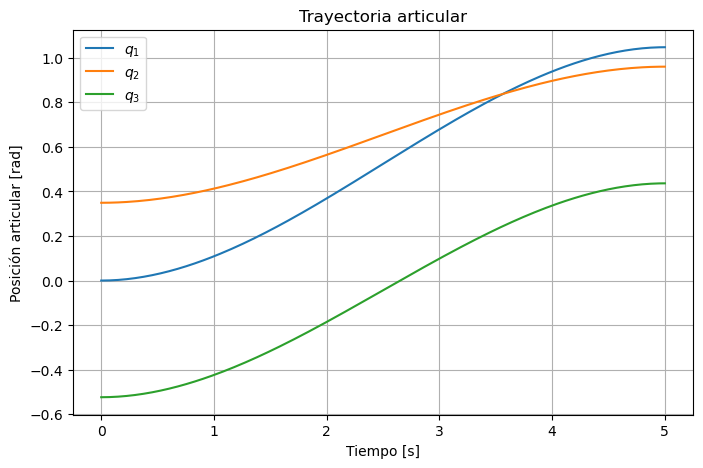

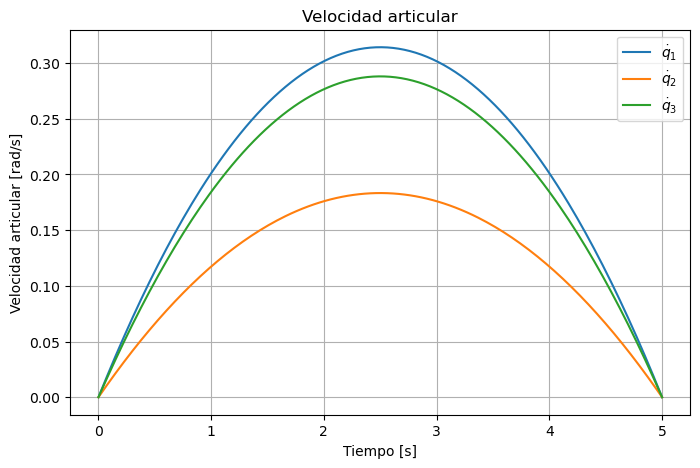

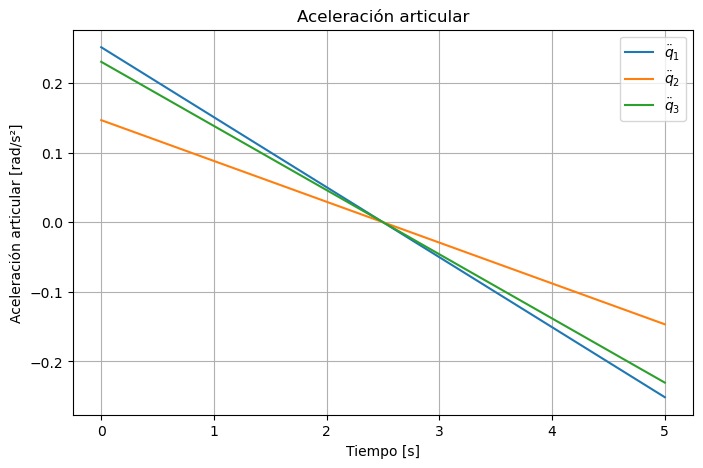

In [17]:
# ---------------------------------------------------------
# Gráficas de posición, velocidad y aceleración articular
# ---------------------------------------------------------

plt.figure(figsize=(8, 5))
plt.plot(t, q_traj[0], label=r"$q_1$")
plt.plot(t, q_traj[1], label=r"$q_2$")
plt.plot(t, q_traj[2], label=r"$q_3$")
plt.xlabel("Tiempo [s]")
plt.ylabel("Posición articular [rad]")
plt.title("Trayectoria articular")
plt.grid(True)
plt.legend()
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(t, dq_traj[0], label=r"$\dot{q}_1$")
plt.plot(t, dq_traj[1], label=r"$\dot{q}_2$")
plt.plot(t, dq_traj[2], label=r"$\dot{q}_3$")
plt.xlabel("Tiempo [s]")
plt.ylabel("Velocidad articular [rad/s]")
plt.title("Velocidad articular")
plt.grid(True)
plt.legend()
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(t, ddq_traj[0], label=r"$\ddot{q}_1$")
plt.plot(t, ddq_traj[1], label=r"$\ddot{q}_2$")
plt.plot(t, ddq_traj[2], label=r"$\ddot{q}_3$")
plt.xlabel("Tiempo [s]")
plt.ylabel("Aceleración articular [rad/s²]")
plt.title("Aceleración articular")
plt.grid(True)
plt.legend()
plt.show()

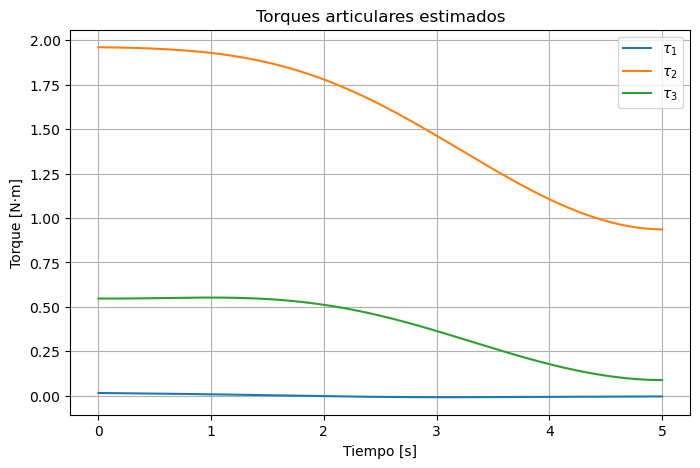

,Articulación,Torque máximo absoluto [N·m]
0,tau_1,0.016167
1,tau_2,1.960078
2,tau_3,0.552611


In [18]:
# ---------------------------------------------------------
# Evaluación de torques durante la trayectoria
# ---------------------------------------------------------

# Función numérica del vector de torques
tau_func = sp.lambdify(
    (q1, q2, q3, dq1, dq2, dq3, ddq1, ddq2, ddq3),
    tau_robot,
    "numpy"
)

tau_traj = np.zeros((3, N))

for k in range(N):
    tau_k = tau_func(
        q_traj[0, k], q_traj[1, k], q_traj[2, k],
        dq_traj[0, k], dq_traj[1, k], dq_traj[2, k],
        ddq_traj[0, k], ddq_traj[1, k], ddq_traj[2, k]
    )
    
    tau_traj[:, k] = np.array(tau_k, dtype=float).reshape(3)

# Gráfica de torques
plt.figure(figsize=(8, 5))
plt.plot(t, tau_traj[0], label=r"$\tau_1$")
plt.plot(t, tau_traj[1], label=r"$\tau_2$")
plt.plot(t, tau_traj[2], label=r"$\tau_3$")
plt.xlabel("Tiempo [s]")
plt.ylabel("Torque [N·m]")
plt.title("Torques articulares estimados")
plt.grid(True)
plt.legend()
plt.show()

# Valores máximos absolutos
tau_max = np.max(np.abs(tau_traj), axis=1)

tabla_torques = pd.DataFrame({
    "Articulación": [r"tau_1", r"tau_2", r"tau_3"],
    "Torque máximo absoluto [N·m]": tau_max
})

tabla_torques

In [19]:
# ---------------------------------------------------------
# Resumen numérico de resultados dinámicos
# ---------------------------------------------------------

tau_max = np.max(np.abs(tau_traj), axis=1)
tau_min = np.min(tau_traj, axis=1)
tau_prom = np.mean(np.abs(tau_traj), axis=1)

tabla_resumen_torques = pd.DataFrame({
    "Articulación": [r"tau_1", r"tau_2", r"tau_3"],
    "Torque mínimo [N·m]": tau_min,
    "Torque promedio absoluto [N·m]": tau_prom,
    "Torque máximo absoluto [N·m]": tau_max
})

tabla_resumen_torques

,Articulación,Torque mínimo [N·m],Torque promedio absoluto [N·m],Torque máximo absoluto [N·m]
0,tau_1,-0.007704,0.006580,0.016167
1,tau_2,0.935663,1.544065,1.960078
2,tau_3,0.088487,0.384732,0.552611


In [20]:
# ---------------------------------------------------------
# Identificación de la articulación más exigida
# ---------------------------------------------------------

articulacion_max = np.argmax(tau_max) + 1
valor_max = tau_max[articulacion_max - 1]

print(f"La articulación con mayor demanda de torque es tau_{articulacion_max}.")
print(f"Torque máximo absoluto: {valor_max:.6f} N·m")

La articulación con mayor demanda de torque es tau_2.
Torque máximo absoluto: 1.960078 N·m


# 11. Discusión de resultados

A partir de la trayectoria articular propuesta, se evaluó el modelo dinámico del robot manipulador 3R. Las gráficas de posición, velocidad y aceleración muestran un comportamiento suave, debido a que se utilizó una interpolación polinomial cúbica entre la configuración inicial y la configuración final. Esto evita cambios bruscos al inicio y al final del movimiento, lo cual es conveniente para reducir exigencias innecesarias sobre los actuadores.

En la postura estática de prueba, las velocidades y aceleraciones articulares se consideraron iguales a cero. Por esta razón, los torques obtenidos corresponden principalmente al efecto gravitacional del robot. En dicha condición se obtuvo un torque aproximado de (0\ \text{N·m}) para (\tau_1), (1.55348\ \text{N·m}) para (\tau_2) y (0.497247\ \text{N·m}) para (\tau_3). Esto indica que, en la configuración evaluada, la segunda articulación es la que debe soportar la mayor carga estática.

Durante la trayectoria completa, los torques máximos absolutos obtenidos fueron (0.016167\ \text{N·m}) para (\tau_1), (1.960078\ \text{N·m}) para (\tau_2) y (0.552611\ \text{N·m}) para (\tau_3). Con base en estos resultados, la articulación con mayor demanda de torque fue (\tau_2), con un valor máximo absoluto de (1.960078\ \text{N·m}).

Este comportamiento es coherente con la estructura física del robot, ya que la segunda articulación corresponde al movimiento del brazo principal y debe soportar una parte importante del peso de los eslabones posteriores. En comparación, la primera articulación presenta una demanda menor porque su movimiento se modela principalmente como una rotación alrededor del eje vertical de la base, por lo que su contribución gravitacional directa es reducida en esta aproximación.

La tercera articulación presenta una demanda intermedia, con un torque máximo absoluto de (0.552611\ \text{N·m}). Esto se debe a que dicha articulación controla el antebrazo y la extensión final del manipulador, pero no carga la totalidad del sistema como ocurre con la segunda articulación.

Los resultados obtenidos permiten comprobar que el modelo dinámico genera valores numéricos de torque para una trayectoria de prueba. Además, la tabla de resumen permite comparar la demanda de cada articulación e identificar cuál de ellas tendría mayor exigencia en una posible selección de actuadores.

Es importante mencionar que el modelo desarrollado corresponde a una aproximación dinámica simplificada. Aunque se utilizaron masas, centros de masa y momentos de inercia obtenidos desde CAD, se asumió que los centros de masa principales se encuentran proyectados sobre la dirección longitudinal de los eslabones. Esta simplificación permite construir un modelo funcional y comprensible, manteniendo una relación directa con los parámetros físicos reales del robot.

En un desarrollo posterior, el modelo podría refinarse utilizando las matrices completas de inercia de cada eslabón, considerando todos los productos de inercia y realizando una transformación rigurosa entre los sistemas de referencia locales de cada componente y el sistema global del robot.


In [21]:
# ---------------------------------------------------------
# Texto resumen automático de resultados
# ---------------------------------------------------------

print("Resumen de resultados dinámicos")
print("--------------------------------")
print(f"Torque máximo tau_1: {tau_max[0]:.6f} N·m")
print(f"Torque máximo tau_2: {tau_max[1]:.6f} N·m")
print(f"Torque máximo tau_3: {tau_max[2]:.6f} N·m")
print()
print(f"Articulación más exigida: tau_{articulacion_max}")
print(f"Torque máximo absoluto global: {valor_max:.6f} N·m")

Resumen de resultados dinámicos
--------------------------------
Torque máximo tau_1: 0.016167 N·m
Torque máximo tau_2: 1.960078 N·m
Torque máximo tau_3: 0.552611 N·m

Articulación más exigida: tau_2
Torque máximo absoluto global: 1.960078 N·m


# 12. Conclusiones

## Conclusión individual — Baruch Villarreal Hinojosa

Durante el desarrollo de este proyecto fue posible comprender la importancia de obtener correctamente los parámetros físicos de un robot antes de formular su modelo dinámico. A partir del modelo CAD se identificaron las masas, centros de masa, momentos de inercia y dimensiones principales de un robot manipulador 3R. Estos datos fueron convertidos al Sistema Internacional para poder utilizarlos dentro de las ecuaciones dinámicas.

El modelo dinámico se formuló mediante el método de Euler-Lagrange, partiendo de la energía cinética y potencial del sistema. Esto permitió obtener una expresión general para los torques articulares en función de las posiciones, velocidades y aceleraciones del robot. Además, la evaluación numérica sobre una trayectoria de prueba permitió observar cómo varía el torque requerido en cada articulación.

El proyecto permitió relacionar el diseño mecánico del robot con su comportamiento dinámico. También se observó que las articulaciones más cercanas a la base tienden a presentar mayor demanda de torque, debido a que soportan mayor carga de los eslabones posteriores. Con esto se comprobó que los datos obtenidos desde CAD son fundamentales para realizar análisis dinámicos más realistas.

## Conclusión individual — Luis Ángel Pérez Castro

La realización de este proyecto permitió integrar conceptos de cinemática, dinámica, modelado CAD y análisis mediante herramientas computacionales. Primero se definió la geometría principal del robot 3R y posteriormente se utilizaron los datos físicos obtenidos del modelo CAD para construir un modelo dinámico simplificado.

El uso del método de Euler-Lagrange permitió obtener las ecuaciones de movimiento del robot de manera ordenada, considerando la energía cinética y la energía potencial de los eslabones. Aunque se trabajó con una aproximación simplificada de los centros de masa, el modelo obtenido permite estimar los torques requeridos por las articulaciones durante una trayectoria articular suave.

Los resultados muestran que el modelo es capaz de generar valores numéricos de torque y permite comparar la exigencia entre articulaciones. Esto puede servir como una base para análisis posteriores, como selección de motores, simulación dinámica o implementación de estrategias de control.

## Conclusión general

En este proyecto se obtuvo y documentó la información física necesaria para generar el modelo dinámico de un robot manipulador 3R. A partir del modelo CAD se identificaron las dimensiones principales, masas, centros de masa y matrices de inercia de los componentes del robot. Posteriormente, estos datos se convirtieron al Sistema Internacional de unidades para ser utilizados dentro del modelo matemático.

El robot fue representado como un manipulador serial de tres articulaciones rotacionales. Primero se desarrolló el modelo cinemático directo para describir la posición del efector final en función de las variables articulares. Después se formuló el modelo dinámico mediante Euler-Lagrange, obteniendo una expresión general para los torques articulares:

$$
\tau = M(q)\ddot{q} + C(q,\dot{q})\dot{q} + G(q)
$$

La evaluación del modelo sobre una trayectoria articular suave permitió obtener gráficas de posición, velocidad, aceleración y torque. Los torques máximos absolutos obtenidos fueron $0.016167$ N·m para $\tau_1$, $1.960078$ N·m para $\tau_2$ y $0.552611$ N·m para $\tau_3$. Con estos resultados se identificó que la segunda articulación fue la más exigida dinámicamente, lo cual es consistente con la configuración del robot, ya que dicha articulación soporta una parte importante del peso y movimiento del brazo principal y de los eslabones posteriores.


# 13. Referencias

1. Craig, J. J. (2005). *Introduction to Robotics: Mechanics and Control*. Pearson Prentice Hall.

2. Spong, M. W., Hutchinson, S., & Vidyasagar, M. (2006). *Robot Modeling and Control*. John Wiley & Sons.

3. Siciliano, B., Sciavicco, L., Villani, L., & Oriolo, G. (2009). *Robotics: Modelling, Planning and Control*. Springer.

4. Corke, P. (2017). *Robotics, Vision and Control*. Springer.

5. Autodesk Inventor. Propiedades físicas del modelo CAD del robot manipulador 3R.

6. Material de clase de Robótica, Facultad de Ingeniería, UNAM. Semestre 2026-2.
